![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

path = '/Users/alex/Documents/Pace/Classes/Junior/Spring/Data Analytics/Weekly Task 5/Untitled/weekly-task-5-atuosto1/weekly task 5/'
city=pd.read_csv(path+'us-cities-top-1k-multi-year.csv')
city

,City,State,Population,lat,lon,year
0,Marysville,Washington,63269,48.051764,-122.177082,2014
1,Perris,California,72326,33.782519,-117.228648,2014
2,Cleveland,Ohio,390113,41.499320,-81.694361,2014
3,Worcester,Massachusetts,182544,42.262593,-71.802293,2014
4,Columbia,South Carolina,133358,34.000710,-81.034814,2014
...,...,...,...,...,...,...
3995,West New York,New Jersey,724261,40.787879,-74.014306,2018
3996,Everett,Massachusetts,723882,42.408430,-71.053663,2018
3997,Linden,New Jersey,663947,40.622048,-74.244590,2018
3998,Asheville,North Carolina,492462,35.595058,-82.551487,2018


Text(0, 0.5, 'Population in Millions')

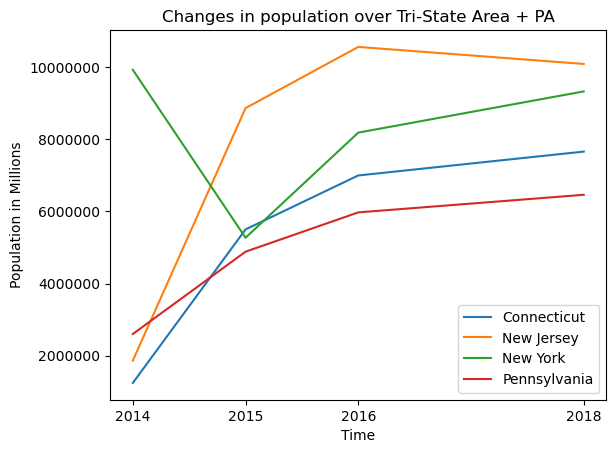

In [9]:
select_city = city[(city['State']=='New Jersey') | (city['State'] == 'Pennsylvania')|
                     (city['State'] == 'New York') |(city['State'] == 'Connecticut')]
select_city
year_pop_state = select_city[['year','Population', 'State']].drop_duplicates().groupby(['year', 'State']).sum().reset_index()
year_pop_state
states= year_pop_state['State'].unique()
years=year_pop_state['year'].unique

for s in list(states):
    forloopyear=year_pop_state[(year_pop_state['State']==str(s))]
    plt.plot(forloopyear['year'].astype(int),forloopyear['Population'],label=s)
plt.xticks(year_pop_state['year'].unique().astype(int))
plt.legend()
plt.ticklabel_format(style='plain')
plt.title("Changes in population over Tri-State Area + PA", loc='center', fontsize=12, fontweight=0) #more detailed options! yay!
plt.xlabel("Time")
plt.ylabel("Population in Millions")

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

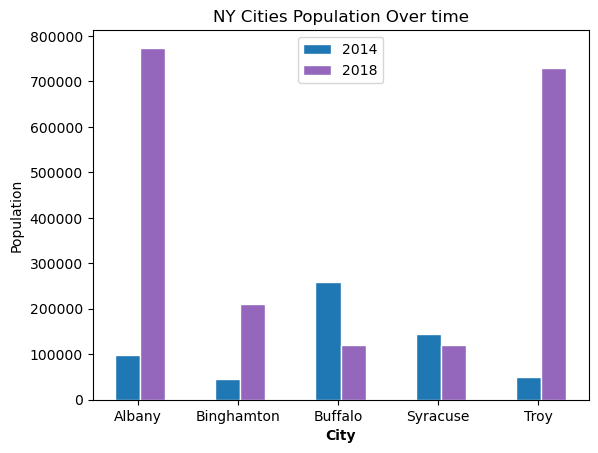

In [10]:
import numpy as np
ny = city[city['State']=='New York']
ny_year_pop_state = ny[['year','Population', 'City']].drop_duplicates().groupby(['year','City']).sum().reset_index()
nycities=list(ny_year_pop_state['City'].unique())
ny_year_pop_state['City']

nyused = ny_year_pop_state[(ny_year_pop_state['City']=='Albany') | (ny_year_pop_state['City']=='Binghamton')|
                    ((ny_year_pop_state['City']=='Buffalo')) |(ny_year_pop_state['City']=='Syracuse')|(ny_year_pop_state['City']=='Troy')]


oldbar=nyused['Population'][nyused['year']==2014]
newbar=nyused['Population'][nyused['year']==2018]
oldbar,newbar

barWidth = 0.25

r1 = np.arange(len(oldbar))
r2 = [x + barWidth for x in r1]
 
# Make the plot
plt.bar(r1, oldbar, color='tab:blue', width=barWidth, edgecolor='white', label='2014')
plt.bar(r2, newbar, color='tab:purple', width=barWidth, edgecolor='white', label='2018')
 
# # Add xticks on the middle of the group bars
plt.xlabel('City', fontweight='bold')
plt.xticks([r + .1 for r in range(len(oldbar))], ['Albany','Binghamton','Buffalo','Syracuse','Troy'])
plt.ylabel('Population')
plt.title("NY Cities Population Over time")
 
# #  Create legend & Show graphic
plt.legend()
plt.show()

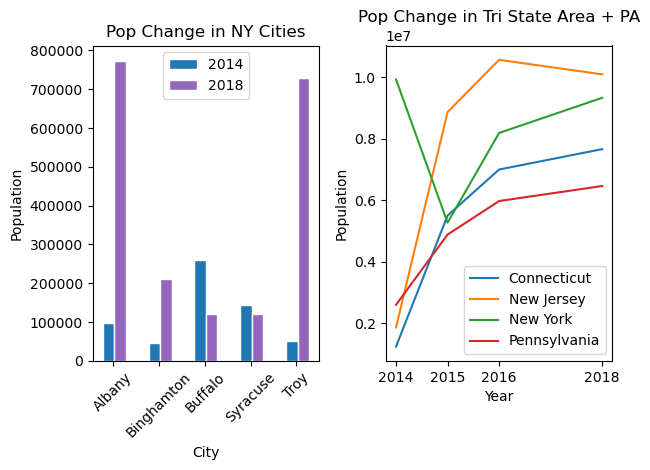

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 2)

ax1=plt.subplot(1,2,1)
ax1.bar(r1, oldbar, color='tab:blue', width=barWidth, edgecolor='white', label='2014')
ax1.bar(r2, newbar, color='tab:purple', width=barWidth, edgecolor='white', label='2018')
ax1.set_title('Pop Change in NY Cities')
ax1.set_xticks([r + .1 for r in range(len(oldbar))], ['Albany','Binghamton','Buffalo','Syracuse','Troy'],rotation=45)
ax1.set_ylabel('Population')
ax1.set_xlabel('City')
ax1.legend()

ax2=plt.subplot(1,2,2)
for s in list(states):
    forloopyear=year_pop_state[(year_pop_state['State']==str(s))]
    ax2.plot(forloopyear['year'].astype(int),forloopyear['Population'],label=s)


ax2.set_xticks(year_pop_state['year'].unique().astype(int))
ax2.legend()
ax2.set_title('Pop Change in Tri State Area + PA')
ax2.set_ylabel('Population',loc='center')
ax2.set_xlabel('Year')

fig.tight_layout()


## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

In [12]:
jobauto=pd.read_csv(path+'job-automation-probability.csv')
jobauto.columns



Index(['_ - rank', '_ - code', 'prob', 'Average annual wage', 'education',
       'occupation', 'short occupation', 'len', 'probability', 'numbEmployed',
       'median_ann_wage', 'employed_may2016', 'average_ann_wage'],
      dtype='object')

Text(0.5, 1.0, 'Count vs Probability of having Job Automation')

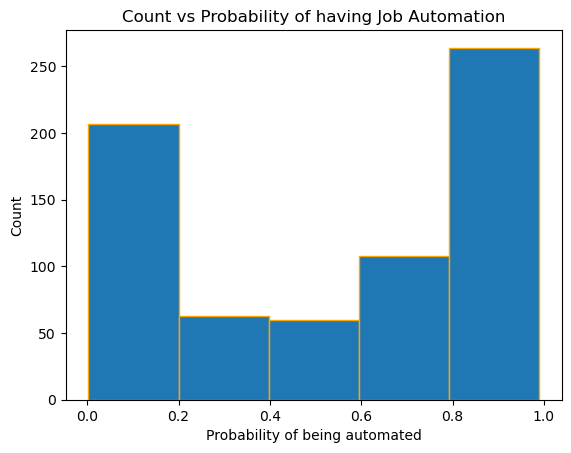

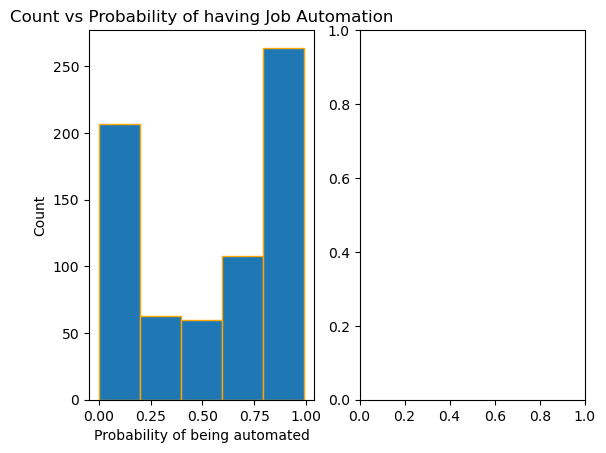

In [13]:
plt.hist(jobauto['prob'],bins=5,edgecolor='orange')
plt.ylabel('Count')
plt.xlabel('Probability of being automated')
plt.title('Count vs Probability of having Job Automation')

figure,ax=plt.subplots(nrows=1,ncols=2)
ax3=plt.subplot(1,2,1)
ax3.hist(jobauto['prob'],bins=5,edgecolor='orange')
ax3.set_ylabel('Count')
ax3.set_xlabel('Probability of being automated')
ax3.set_title('Count vs Probability of having Job Automation')

#^^ is going to be AX1, actually ax3 bc i dont want to fuck up stuff from before

Text(0.5, 1.0, 'Scatterplot of having Job Automation')

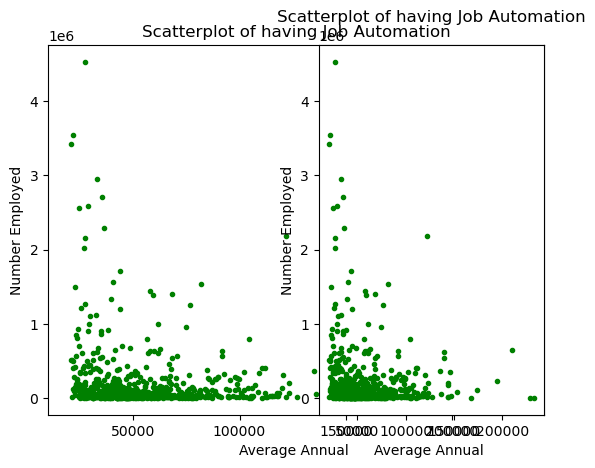

In [14]:
avwage=jobauto['Average annual wage']
numemp=jobauto['numbEmployed']

plt.plot('Average annual wage','numbEmployed',data=jobauto,marker='.',linestyle='none',color='green')
plt.ylabel('Number Employed')
plt.xlabel('Average Annual ')
plt.title('Scatterplot of having Job Automation')
ax4=plt.subplot(1,2,2)
ax4.plot('Average annual wage','numbEmployed',data=jobauto,marker='.',linestyle='none',color='green')
ax4.set_ylabel('Number Employed')
ax4.set_xlabel('Average Annual ')
ax4.set_title('Scatterplot of having Job Automation')

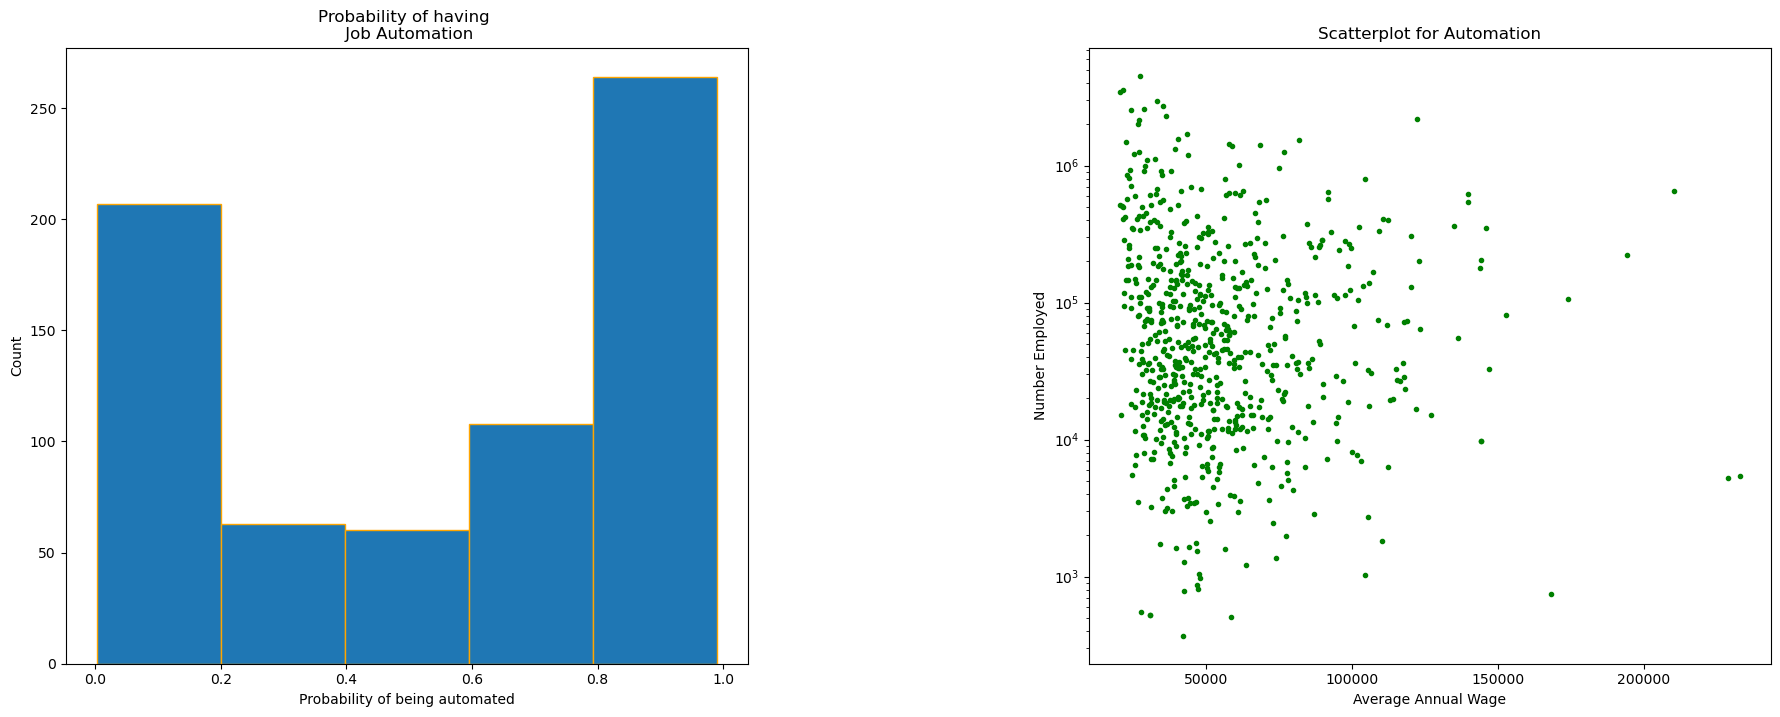

In [15]:
figure,ax=plt.subplots(nrows=1,ncols=2,figsize=(22,8))
ax3=plt.subplot(1,2,1)
ax3.hist(jobauto['prob'],bins=5,edgecolor='orange')
ax3.set_ylabel('Count')
ax3.set_xlabel('Probability of being automated')
ax3.set_title('Probability of having \n Job Automation')

ax4=plt.subplot(1,2,2)
ax4.plot('Average annual wage','numbEmployed',data=jobauto,marker='.',linestyle='none',color='green')
ax4.set_ylabel('Number Employed')
ax4.set_xlabel('Average Annual Wage')
ax4.set_title('Scatterplot for Automation')
ax4.set_yscale('log')
fig.tight_layout()
plt.subplots_adjust(wspace=0.5)
plt.savefig('Alex Attempt2.png', format = 'png', transparent= False)

In [17]:
plt.savefig('Alex Attempt3.png', format = 'png', transparent= False)

<Figure size 640x480 with 0 Axes>